In [1]:
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
import pandas as pd

In [2]:
iris = load_iris()

In [3]:
X = iris.data
y = iris.target

In [4]:
X.shape

(150, 4)

<Axes: >

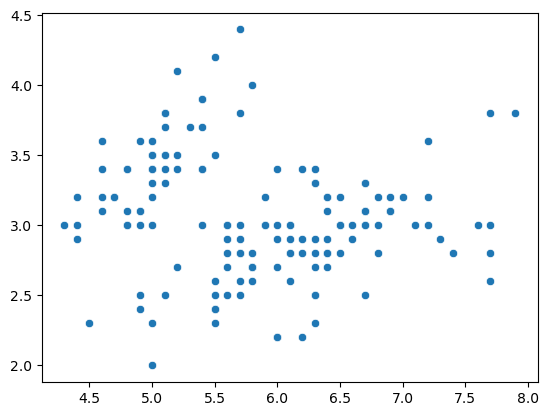

In [6]:
sns.scatterplot(x=X[:,0], y=X[:,1])

In [7]:
# scaling the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [15]:
# optional - dimensionality reduction using PCA

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_scaled)

In [16]:
# elbow method

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_)

In [17]:
wcss

[574.8792432000105,
 197.40381604541284,
 116.01774316704254,
 90.1290614952116,
 80.04073818154853,
 57.68606553599851,
 49.5456644167657,
 39.74419724868251,
 34.25399023459756,
 29.34677258032454]

<Axes: >

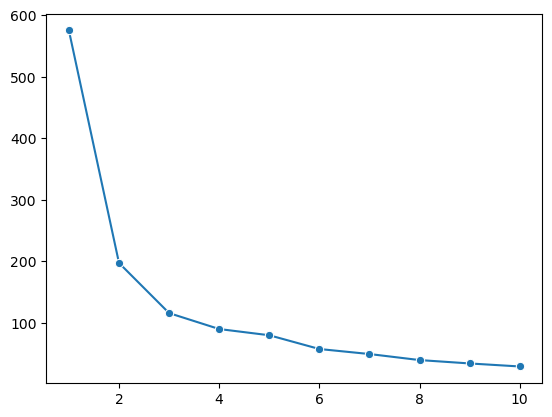

In [18]:
sns.lineplot(x=range(1, 11), y=wcss, marker="o")

<Axes: >

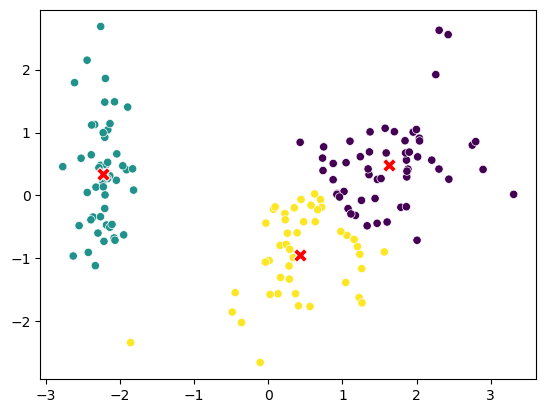

In [27]:
# Kmeans

kmeans = KMeans(n_clusters=3, random_state=10)
labels = kmeans.fit_predict(pca_data)

sns.scatterplot(x=pca_data[:,0], y=pca_data[:,1], c=labels)
sns.scatterplot(x=kmeans.cluster_centers_[:,0], y=kmeans.cluster_centers_[:,1], marker="X", c="red", s=100)